In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 29
day = 23

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
using travel lag of 7.357357357357358 cm
brain region PAR is not disqualifying for spatial cells
brain region PAR is not disqualifying for spatial cells
brain region PAR is not disqualifying for spatial cells
brain region PAR is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm3 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brain region ENTm1 is not disqualifying for spatial cells
brai

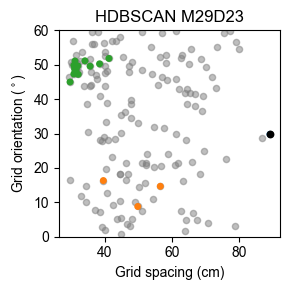

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
29 23
for module 1, there are 15 cells
for module 0, there are 3 cells
plotting vr rate maps using cluster_ids [132, 160, 184, 191, 194, 202, 213, 214, 216, 217, 219, 362, 389, 411, 416]


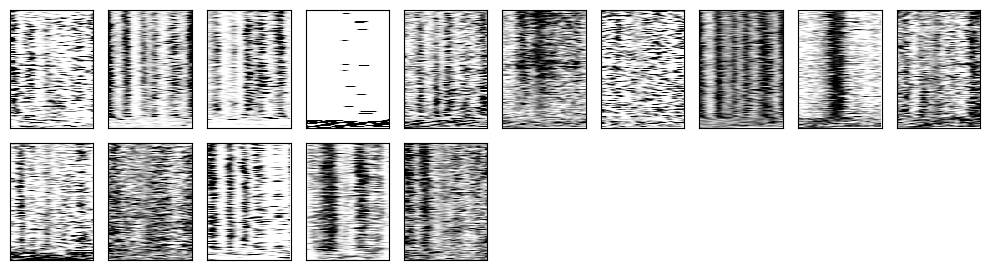

plotting vr rate maps using cluster_ids [332, 425, 430]


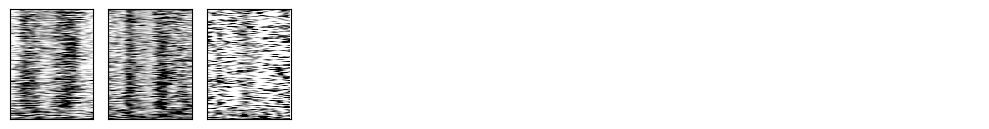

plotting vr rate maps using cluster_ids [24, 28, 53, 61, 65, 79, 81, 86, 89, 95, 104, 108, 144, 157, 163, 169, 186, 205, 210, 211, 221, 226, 231, 239, 241, 247, 249, 251, 255, 256, 259, 266, 267, 269, 270, 278, 292, 293, 296, 297, 301, 311, 312, 315, 318, 321, 323, 327, 329, 334, 340, 341, 342, 345, 346, 349, 350, 352, 353, 354, 356, 363, 366, 369, 370, 371, 373, 374, 375, 376, 377, 378, 380, 382, 383, 385, 387, 391, 392, 393, 394, 396, 397, 398, 399, 400, 403, 404, 405, 409, 412, 414, 418, 419, 420, 422, 426, 427, 429, 433, 434, 440, 446, 450, 451, 452, 457, 461, 462, 464, 466, 467, 469, 472]


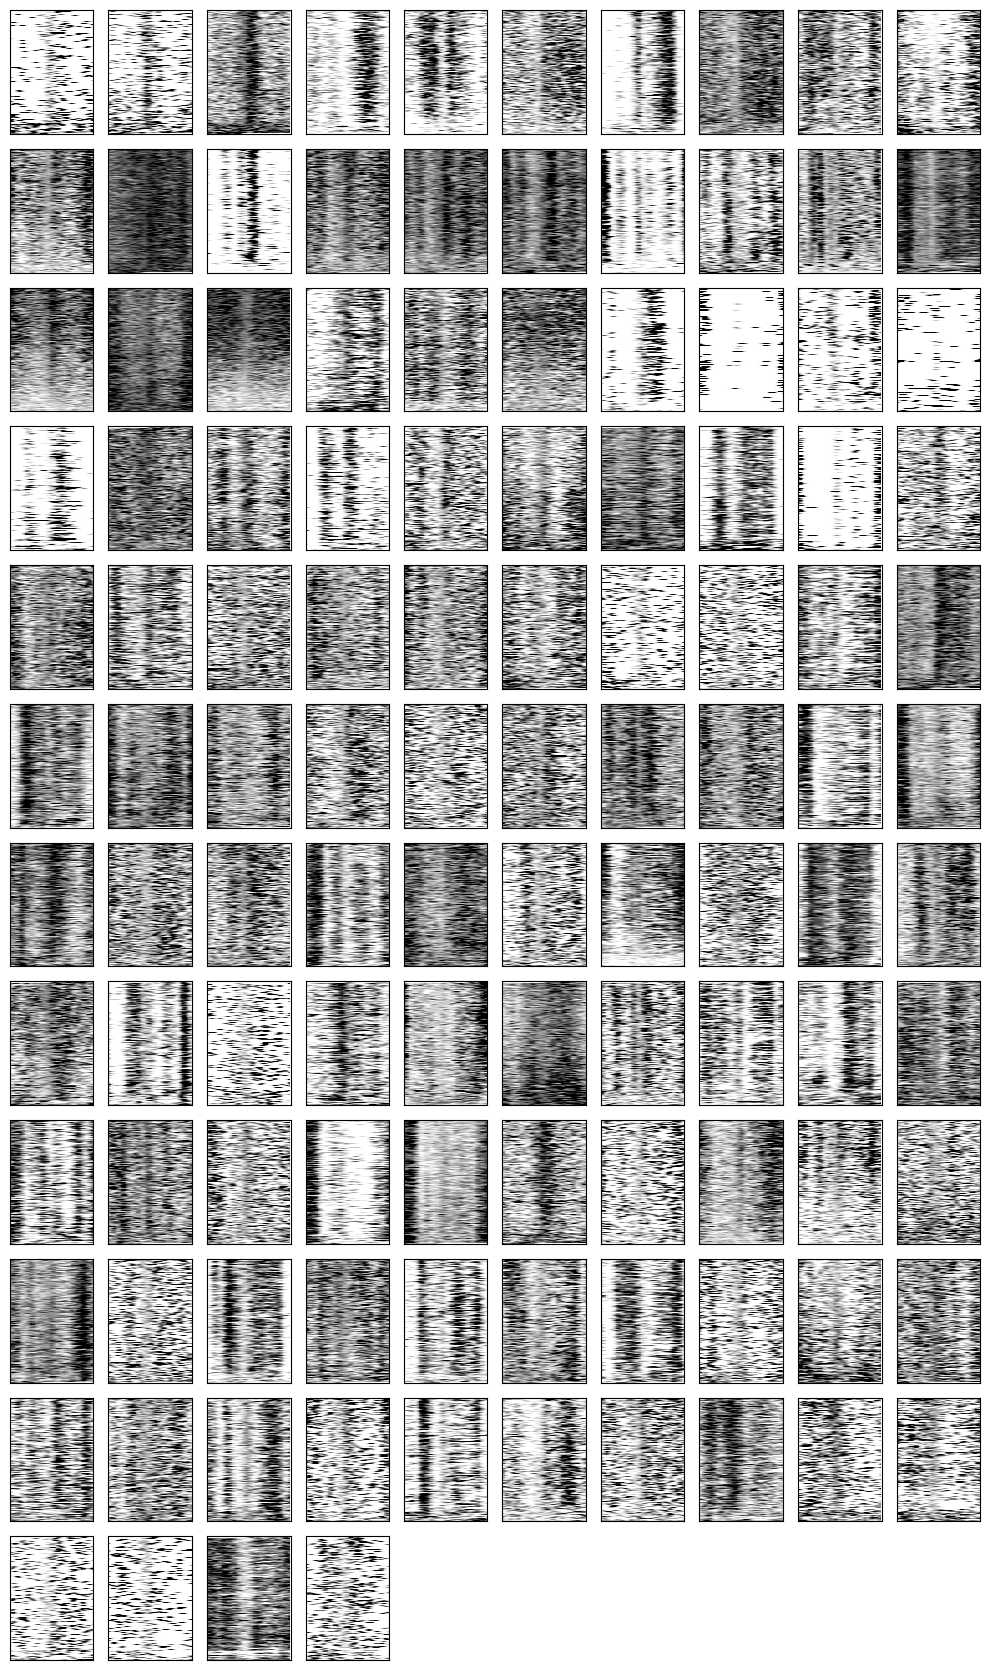

plotting vr rate maps using cluster_ids [20, 26, 29, 30, 32, 33, 34, 133, 198, 244, 268, 272, 275, 317, 335, 336, 359, 364, 368, 388, 408, 444, 447, 454, 458, 459, 463]


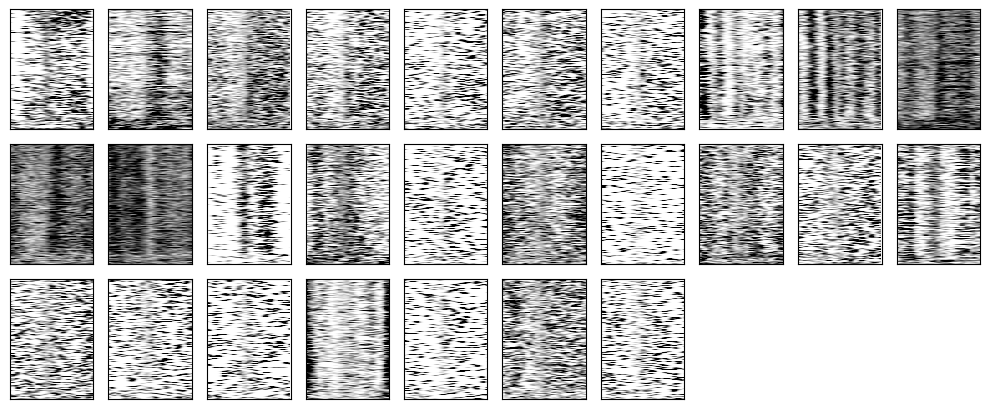

plotting vr rate maps using cluster_ids [132, 160, 184, 191, 194, 202, 213, 214, 216, 217, 219, 332, 343, 362, 389, 411, 416, 425, 430]


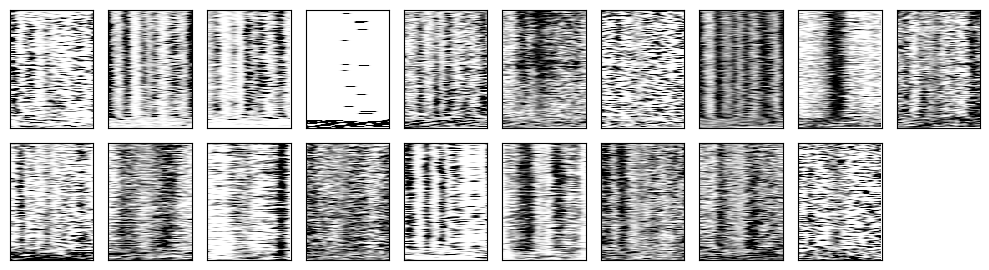

plotting vr rate maps using cluster_ids []
plotting vr rate maps using cluster_ids [332 343 425 430]


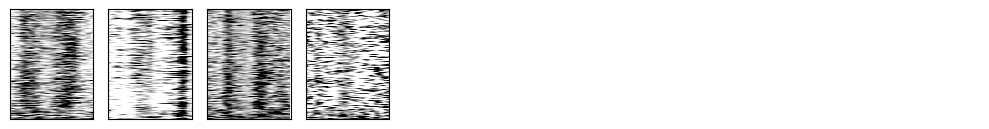

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

plot_vr_rate_maps(mouse, day, np.setdiff1d(gcs.cluster_id.values, g_m_cluster_ids[0]), label=f'nocomodular_grid_cells', figpath=fig_path)

In [4]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
tcs_of, tcs_time_of, beh_of, clusters_of, ep_OF = compute_of_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False, optimal_shift=gcs.travel[0])
last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

x_pos_in_time_OF = np.array(beh_of['head_x'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))
y_pos_in_time_OF = np.array(beh_of['head_y'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

if np.any(np.isnan(x_pos_in_time_OF)):
    series = pd.Series(x_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    x_pos_in_time_OF = np.array(filled_series)

if np.any(np.isnan(y_pos_in_time_OF)):
    series = pd.Series(y_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    y_pos_in_time_OF = np.array(filled_series)

In [5]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

In [7]:
test_grid_cell_1 = 214  # cm
test_grid_cell_2 = 332  # ncm
test_ngs_cell_1 = 340   # ngs

import random

# Prepare grid predictors (remove test cells if present, then shuffle and select 10)
grid_predictors = g_m_cluster_ids[0].copy()
for test_id in [test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1]:
    if test_id in grid_predictors:
        grid_predictors.remove(test_id)
random.shuffle(grid_predictors)
grid_predictors = grid_predictors[:10]

# Prepare NGS predictors (remove test cells if present, then shuffle and select 10)
ngs_predictors = ngs.cluster_id.values.tolist()
for test_id in [test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1]:
    if test_id in ngs_predictors:
        ngs_predictors.remove(test_id)
random.shuffle(ngs_predictors)
ngs_predictors = ngs_predictors[:10]

In [8]:
def predict_xgboost_traces(
    target_id,
    tcs_time,
    pos_in_time,
    grid_predictors,
    ngs_predictors,
    xgb_history,
    gaussian_filter_nan,
    n_grid=10,
    n_ngs=10
):
    """
    Predicts activity for a target cell using XGBoost with various covariate sets.

    Returns a dictionary of predictions and cross-validated pR2 values.
    """
    y = np.array(tcs_time[target_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)

    # --- GRID CELLS ---
    Xg_1 = np.stack([np.array(tcs_time[grid_predictors[0]])]).T
    Xpos_g_1 = np.stack([pos_in_time, np.array(tcs_time[grid_predictors[0]])]).T
    Xg_5 = np.column_stack([np.array(tcs_time[cid]) for cid in grid_predictors[:5]])
    Xpos_g_5 = np.column_stack((pos_in_time, Xg_5))
    Xg_10 = np.column_stack([np.array(tcs_time[cid]) for cid in grid_predictors[:n_grid]])
    Xpos_g_10 = np.column_stack((pos_in_time, Xg_10))

    # --- NGS CELLS ---
    Xngs_1 = np.stack([np.array(tcs_time[ngs_predictors[0]])]).T
    Xpos_ngs_1 = np.stack([pos_in_time, np.array(tcs_time[ngs_predictors[0]])]).T
    Xngs_5 = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_predictors[:5]])
    Xpos_ngs_5 = np.column_stack((pos_in_time, Xngs_5))
    Xngs_10 = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_predictors[:n_ngs]])
    Xpos_ngs_10 = np.column_stack((pos_in_time, Xngs_10))

    # --- POSITION ONLY ---
    Xpos = np.stack([pos_in_time]).T

    # --- FIT MODELS ---
    results = {}

    # Position only
    results['pos'] = xgb_history.fit_cv(Xpos, y, verbose=0, continuous_folds=True)

    # Grid predictors
    results['g1'] = xgb_history.fit_cv(Xg_1, y, verbose=0, continuous_folds=True)
    results['g5'] = xgb_history.fit_cv(Xg_5, y, verbose=0, continuous_folds=True)
    results['g10'] = xgb_history.fit_cv(Xg_10, y, verbose=0, continuous_folds=True)

    # Grid predictors + position
    results['pos_g1'] = xgb_history.fit_cv(Xpos_g_1, y, verbose=0, continuous_folds=True)
    results['pos_g5'] = xgb_history.fit_cv(Xpos_g_5, y, verbose=0, continuous_folds=True)
    results['pos_g10'] = xgb_history.fit_cv(Xpos_g_10, y, verbose=0, continuous_folds=True)

    # NGS predictors
    results['ngs1'] = xgb_history.fit_cv(Xngs_1, y, verbose=0, continuous_folds=True)
    results['ngs5'] = xgb_history.fit_cv(Xngs_5, y, verbose=0, continuous_folds=True)
    results['ngs10'] = xgb_history.fit_cv(Xngs_10, y, verbose=0, continuous_folds=True)

    # NGS predictors + position
    results['pos_ngs1'] = xgb_history.fit_cv(Xpos_ngs_1, y, verbose=0, continuous_folds=True)
    results['pos_ngs5'] = xgb_history.fit_cv(Xpos_ngs_5, y, verbose=0, continuous_folds=True)
    results['pos_ngs10'] = xgb_history.fit_cv(Xpos_ngs_10, y, verbose=0, continuous_folds=True)

    # Also return the true and smoothed target for plotting
    results['y'] = y
    results['y_smoothed'] = y_smoothed

    return results

In [86]:
# Example for three target cells
target_cell_names = [f'Unit {test_grid_cell_1}', f'Unit {test_grid_cell_2}', f'Unit {test_ngs_cell_1}']
target_cell_ids = [test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1]

# Run predictions for each target cell and collect results
results_dict = {}
for cell_name, cell_id in zip(target_cell_names, target_cell_ids):
    results_dict[cell_name] = predict_xgboost_traces(
        target_id=cell_id,
        tcs_time=tcs_time,
        pos_in_time=pos_in_time,
        grid_predictors=grid_predictors,
        ngs_predictors=ngs_predictors,
        xgb_history=xgb_history,
        gaussian_filter_nan=gaussian_filter_nan,
        n_grid=10,
        n_ngs=10
    )

In [101]:
def plot_xgboost_traces(
    results_dict,
    target_cell_names,
    covariate_labels=[
        'pos', 'g1', 'g5', 'g10', 'pos_g1', 'pos_g5', 'pos_g10',
        'ngs1', 'ngs5', 'ngs10', 'pos_ngs1', 'pos_ngs5', 'pos_ngs10'
    ],
    tidy_covariate_labels=[
        'Pos', 'GCn=1', 'GCn=5', 'GCn=10', 'P+GCn=1', 'P+GCn=5', 'P+GCn=10',
        'NGSn=1', 'NGSn=5', 'NGSn=10', 'P+NGSn=1', 'P+NGSn=5', 'P+NGSn=10'
    ],
    true_labels=['y', 'y_smoothed'],
    window=None,
    figsize=(15, 4),
    gain=[1,1,1],
    text_offset=0.0,
    offset_jump=0.0,
    savepath=None,
):
    """
    Plot true and predicted traces for target cells side by side (3 columns) using results_dict directly.
    Each covariate prediction is offset vertically for clarity.
    true_labels are plotted at the top, overlayed, in black and grey (same offset).
    pos at top, then gc, then ngs. Covariate label on left, mean pR2 on right. No axes.
    Offsets are fixed and identical across all subplots.
    Colors: test_grid_cell_1 and test_grid_cell_2 = red, test_ngs_cell_1 = blue.
    text_offset: float, controls vertical shift of all text annotations (in units of offset_step).
    offset_jump: float, additional offset (in units of offset_step) between y/pos and pos_g10/ngs1.
    tidy_covariate_labels: list of strings, used for text on the figure (with n=x as subscript).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Helper to convert "n=x" to subscript in label
    def subscript_n(label):
        import re
        # Replace n=number with $_{n=number}$ for subscript
        return re.sub(r'n=([0-9]+)', r'$_{n=\1}$', label)

    # Order: true_labels (same offset), pos, gc, ngs
    pos_labels = [l for l in covariate_labels if l == 'pos']
    gc_labels = [l for l in covariate_labels if 'g' in l and 'ngs' not in l and l != 'pos']
    ngs_labels = [l for l in covariate_labels if 'ngs' in l]
    ordered_labels = [true_labels[0]] + pos_labels + gc_labels + ngs_labels
    n_offsets = len(ordered_labels)

    # Compute a global offset step based on all traces
    all_true_traces = [results_dict[cell]["y"] for cell in target_cell_names]
    if window is not None:
        all_true_traces = [trace[window[0]:window[1]] for trace in all_true_traces]
    global_max = np.nanmax([np.nanmax(trace) for trace in all_true_traces])
    offset_step = global_max * 1.2 if global_max > 0 else 1

    # Build offsets with jumps
    offsets = []
    for i, label in enumerate(ordered_labels):
        # Add offset_jump after y (true_labels) and after pos_g10
        jump = 0
        if i == 1:  # after y/true_labels
            jump = offset_jump * offset_step
        if 'pos_g10' in ordered_labels and i == ordered_labels.index('pos_g10') + 1:
            jump += offset_jump * offset_step
        if i == 0:
            offsets.append(offset_step * (n_offsets - 1 - i))
        else:
            offsets.append(offsets[-1] - offset_step - jump)

    # Assign colors by test cell: red for grid cells, blue for ngs
    color_map_by_cell = {}
    for cell_name in target_cell_names:
        if '340' in str(cell_name).lower():
            color_map_by_cell[cell_name] = '#3171ae'
        else:
            color_map_by_cell[cell_name] = '#c04744'
    # True label colors
    true_label_colors = ['grey', 'black']

    n_cells = len(target_cell_names)
    fig, axes = plt.subplots(1, n_cells, figsize=figsize, sharey=True)
    if n_cells == 1:
        axes = [axes]
    for i, cell_name in enumerate(target_cell_names):
        ax = axes[i]
        true_trace = results_dict[cell_name]["y"]
        if window is not None:
            t_idx = np.arange(window[0], window[1])
            true_trace = true_trace[window[0]:window[1]]
        else:
            t_idx = np.arange(len(true_trace))
        # Plot true labels at the top, overlayed, with same offset
        true_offset = offsets[0]
        for j, label in enumerate(true_labels):
            if label in results_dict[cell_name]:
                trace = results_dict[cell_name][label]
                if window is not None:
                    trace = trace[window[0]:window[1]]
                ax.plot(t_idx, trace * 2 + true_offset, lw=2, color=true_label_colors[j], alpha=0.8)
                # Add label to left, move up by text_offset*offset_step
                if i == 0:
                    ax.text(
                        t_idx[0] - (0.01 * len(t_idx)),
                        np.nanmean(trace * 2 + true_offset) + text_offset * offset_step,
                        label,
                        color=true_label_colors[j],
                        va='center',
                        ha='right',
                        fontsize=15
                    )
        # Plot predictions for each covariate set with fixed vertical offsets
        for j, cov_label in enumerate(pos_labels + gc_labels + ngs_labels):
            idx = ordered_labels.index(cov_label)
            pred_trace = results_dict[cell_name][cov_label][0]
            if window is not None:
                pred_trace = pred_trace[window[0]:window[1]]
            pr2 = np.nanmean(results_dict[cell_name][cov_label][1])
            color = color_map_by_cell[cell_name]
            offset = offsets[idx]
            # Use tidy label with subscript
            tidy_label = tidy_covariate_labels[j] if tidy_covariate_labels else cov_label
            tidy_label = subscript_n(tidy_label)
            ax.plot(t_idx, pred_trace * gain[i] + offset, lw=1.5, alpha=0.8, color=color)
            # Add covariate label to left, move up by text_offset*offset_step
            if i == 0:
                ax.text(
                    t_idx[0] - (0.01 * len(t_idx)),
                    np.nanmean(pred_trace + offset) + text_offset * offset_step,
                    tidy_label,
                    color=color,
                    va='center',
                    ha='right',
                    fontsize=15
                )
            # Add mean pR2 to right, move up by text_offset*offset_step
            ax.text(
                t_idx[-1] + (0.01 * len(t_idx)),
                np.nanmean(pred_trace + offset) + text_offset * offset_step,
                f'{pr2:.2f}',
                color=color,
                va='center',
                ha='left',
                fontsize=10
            )
        ax.set_title(str(cell_name), fontsize=16)
        # Remove axes
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        # plot a line to show 5 seconds
    axes[-1].plot([window[0], window[0] + 5000/time_bs], [offsets[-1], offsets[-1]], color='black', lw=2)
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath)
    plt.show()

In [112]:
def plot_xgboost_traces(
    results_dict,
    target_cell_names,
    covariate_labels=[
        'pos', 'g1', 'g5', 'g10', 'pos_g1', 'pos_g5', 'pos_g10',
        'ngs1', 'ngs5', 'ngs10', 'pos_ngs1', 'pos_ngs5', 'pos_ngs10'
    ],
    tidy_covariate_labels=[
        'Pos', 'GCn=1', 'GCn=5', 'GCn=10', 'P+GCn=1', 'P+GCn=5', 'P+GCn=10',
        'NGSn=1', 'NGSn=5', 'NGSn=10', 'P+NGSn=1', 'P+NGSn=5', 'P+NGSn=10'
    ],
    true_labels=['y', 'y_smoothed'],
    window=None,
    figsize=(15, 4),
    gain=[1,1,1],
    text_offset=0.0,
    offset_jump=0.0,
    savepath=None,
    time_bs=100,  # ms per bin, adjust as needed
):
    """
    Plot true and predicted traces for target cells side by side (3 columns) using results_dict directly.
    Each covariate prediction is offset vertically for clarity.
    true_labels are plotted at the top, overlayed, in black and grey (same offset).
    pos at top, then gc, then ngs. Covariate label on left, mean pR2 on right. No axes.
    Offsets are fixed and identical across all subplots.
    Colors: test_grid_cell_1 and test_grid_cell_2 = red, test_ngs_cell_1 = blue.
    text_offset: float, controls vertical shift of all text annotations (in units of offset_step).
    offset_jump: float, additional offset (in units of offset_step) between y/pos and pos_g10/ngs1.
    tidy_covariate_labels: list of strings, used for text on the figure (with n=x as subscript).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    def subscript_n(label):
        import re
        return re.sub(r'n=([0-9]+)', r'$_{n=\1}$', label)

    pos_labels = [l for l in covariate_labels if l == 'pos']
    gc_labels = [l for l in covariate_labels if 'g' in l and 'ngs' not in l and l != 'pos']
    ngs_labels = [l for l in covariate_labels if 'ngs' in l]
    ordered_labels = [true_labels[0]] + pos_labels + gc_labels + ngs_labels
    n_offsets = len(ordered_labels)

    all_true_traces = [results_dict[cell]["y"] for cell in target_cell_names]
    if window is not None:
        all_true_traces = [trace[window[0]:window[1]] for trace in all_true_traces]
    global_max = np.nanmax([np.nanmax(trace) for trace in all_true_traces])
    offset_step = global_max * 1.2 if global_max > 0 else 1

    offsets = []
    for i, label in enumerate(ordered_labels):
        jump = 0
        if i == 1:
            jump = offset_jump * offset_step
        if 'pos_g10' in ordered_labels and i == ordered_labels.index('pos_g10') + 1:
            jump += offset_jump * offset_step
        if i == 0:
            offsets.append(offset_step * (n_offsets - 1 - i))
        else:
            offsets.append(offsets[-1] - offset_step - jump)

    color_map_by_cell = {}
    for cell_name in target_cell_names:
        if '340' in str(cell_name).lower():
            color_map_by_cell[cell_name] = '#3171ae'
        else:
            color_map_by_cell[cell_name] = '#c04744'
    true_label_colors = ['grey', 'black']

    n_cells = len(target_cell_names)
    fig, axes = plt.subplots(1, n_cells, figsize=figsize, sharey=True)
    if n_cells == 1:
        axes = [axes]
    for i, cell_name in enumerate(target_cell_names):
        ax = axes[i]
        true_trace = results_dict[cell_name]["y"]
        if window is not None:
            t_idx = np.arange(window[0], window[1])
            true_trace = true_trace[window[0]:window[1]]
        else:
            t_idx = np.arange(len(true_trace))
        true_offset = offsets[0]
        for j, label in enumerate(true_labels):
            if label in results_dict[cell_name]:
                trace = results_dict[cell_name][label]
                if window is not None:
                    trace = trace[window[0]:window[1]]
                ax.plot(t_idx, trace * 2 + true_offset, lw=2, color=true_label_colors[j], alpha=0.8)
                if i == 0:
                    ax.text(
                        t_idx[0] - (0.08 * len(t_idx)),  # shift left of y axis label
                        np.nanmean(trace * 2 + true_offset) + text_offset * offset_step,
                        label,
                        color=true_label_colors[j],
                        va='center',
                        ha='right',
                        fontsize=15
                    )
        for j, cov_label in enumerate(pos_labels + gc_labels + ngs_labels):
            idx = ordered_labels.index(cov_label)
            pred_trace = results_dict[cell_name][cov_label][0]
            if window is not None:
                pred_trace = pred_trace[window[0]:window[1]]
            pr2 = np.nanmean(results_dict[cell_name][cov_label][1])
            color = color_map_by_cell[cell_name]
            offset = offsets[idx]
            tidy_label = tidy_covariate_labels[j] if tidy_covariate_labels else cov_label
            tidy_label = subscript_n(tidy_label)
            if i == 0:
                ax.text(
                    t_idx[0] - (0.08 * len(t_idx)),  # shift left of y axis label
                    np.nanmean(pred_trace + offset) + text_offset * offset_step,
                    tidy_label,
                    color=color,
                    va='center',
                    ha='right',
                    fontsize=15
                )
            ax.plot(t_idx, pred_trace * gain[i] + offset, lw=1.5, alpha=0.8, color=color)
            ax.text(
                t_idx[-1] + (0.01 * len(t_idx)),
                np.nanmean(pred_trace + offset) + text_offset * offset_step,
                f'{pr2:.2f}',
                color=color,
                va='center',
                ha='left',
                fontsize=10
            )
        ax.set_title(str(cell_name), fontsize=16)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
    # Add y axis label to the leftmost plot
    axes[0].set_ylabel('Target prediction', fontsize=18, labelpad=60)
    # plot a line to show 5 seconds
    if window is not None:
        t_start = window[0]
    else:
        t_start = 0
    t_per_bin = time_bs / 1000  # convert ms to s
    bar_len = int(5 / t_per_bin)
    axes[0].plot([t_start, t_start + bar_len], [offsets[-1], offsets[-1]], color='black', lw=2)
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath)
    plt.show()

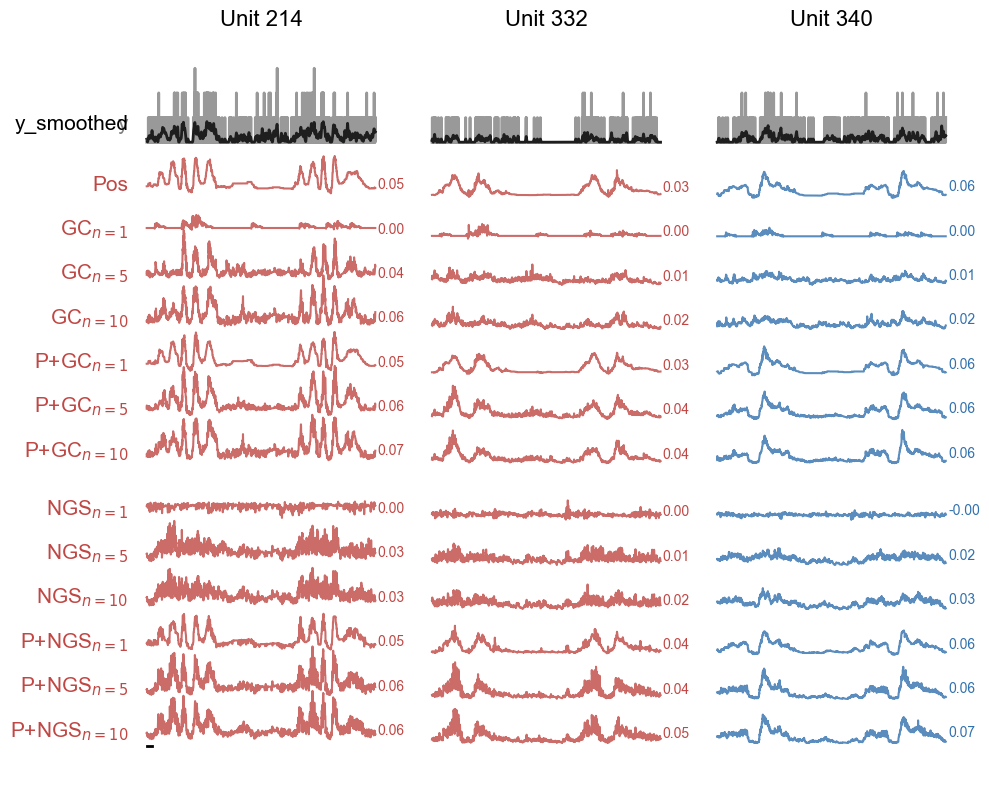

In [113]:
b=-30000
# Now you can call the plotting function
plot_xgboost_traces(results_dict, 
                    target_cell_names,
                    window=(24150, 26150), 
                    figsize=(10, 8),
                    gain=[5, 12, 6],
                    text_offset=0.25,
                    offset_jump=0.3,
                    savepath=f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_traces.pdf')

-54000


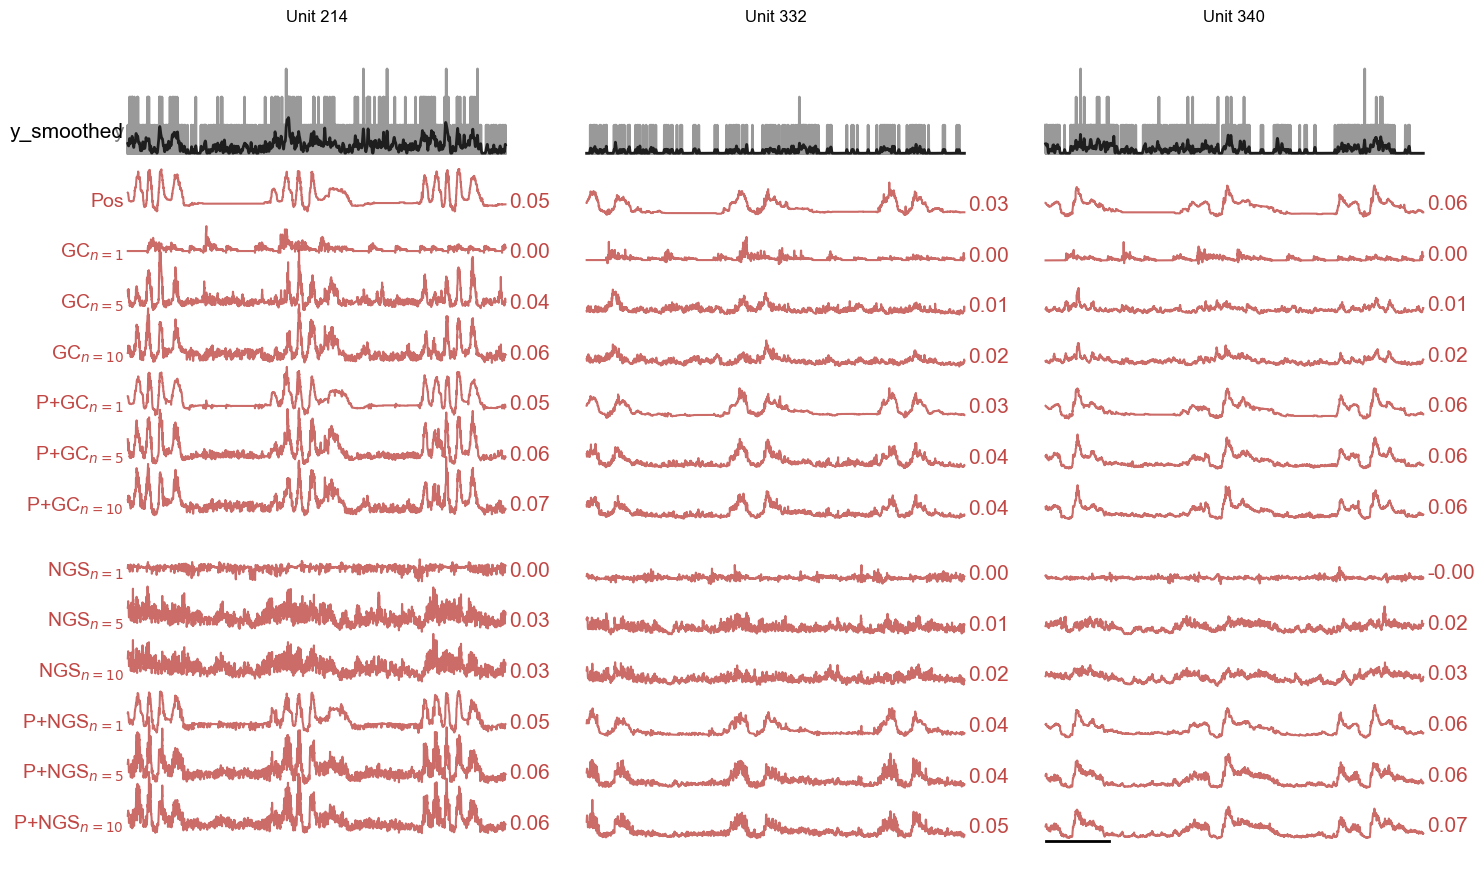

-50000


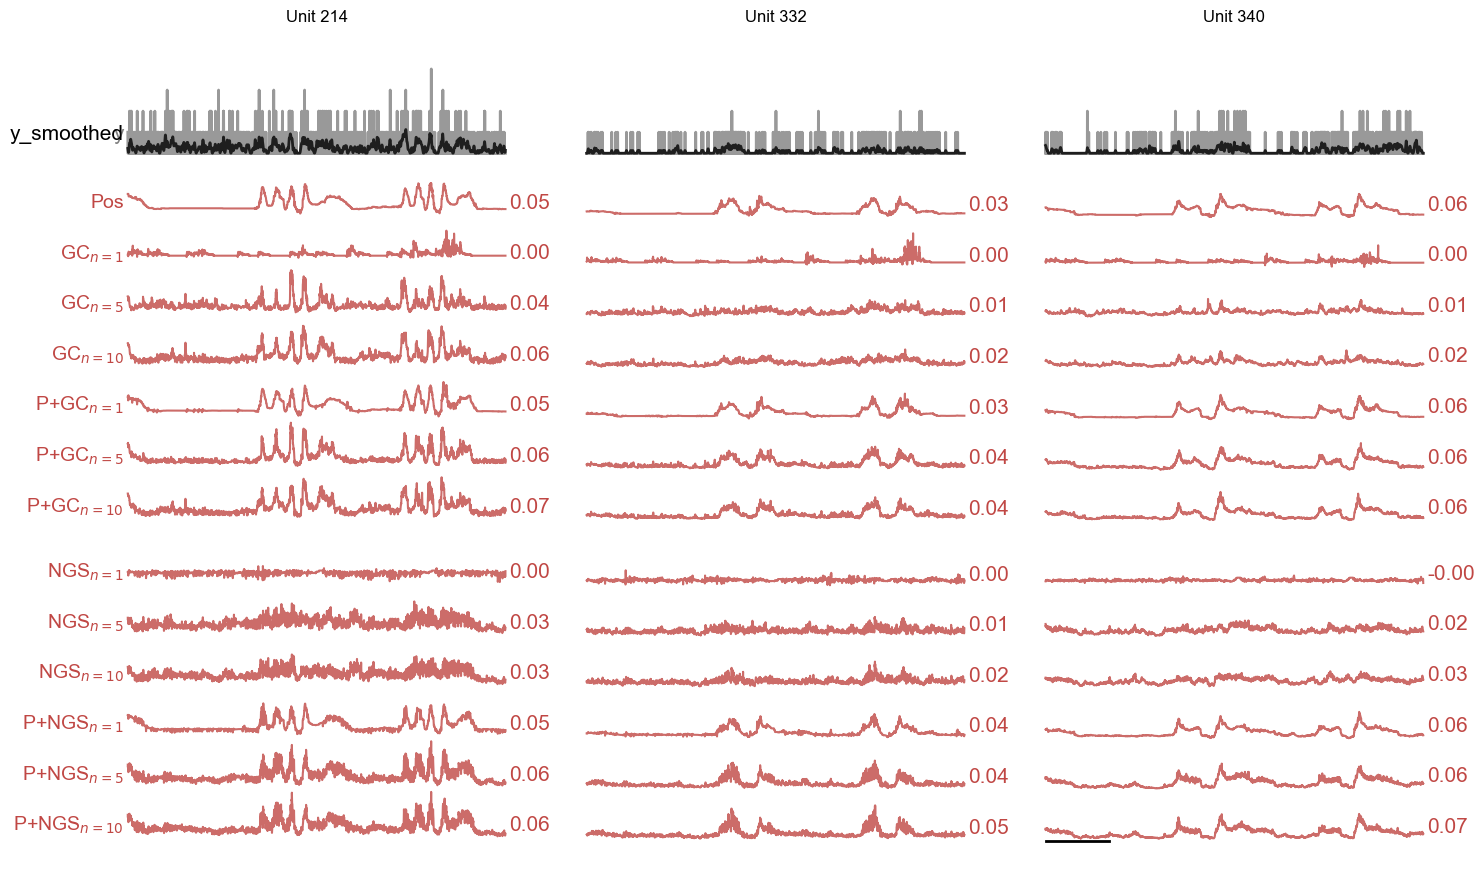

-46000


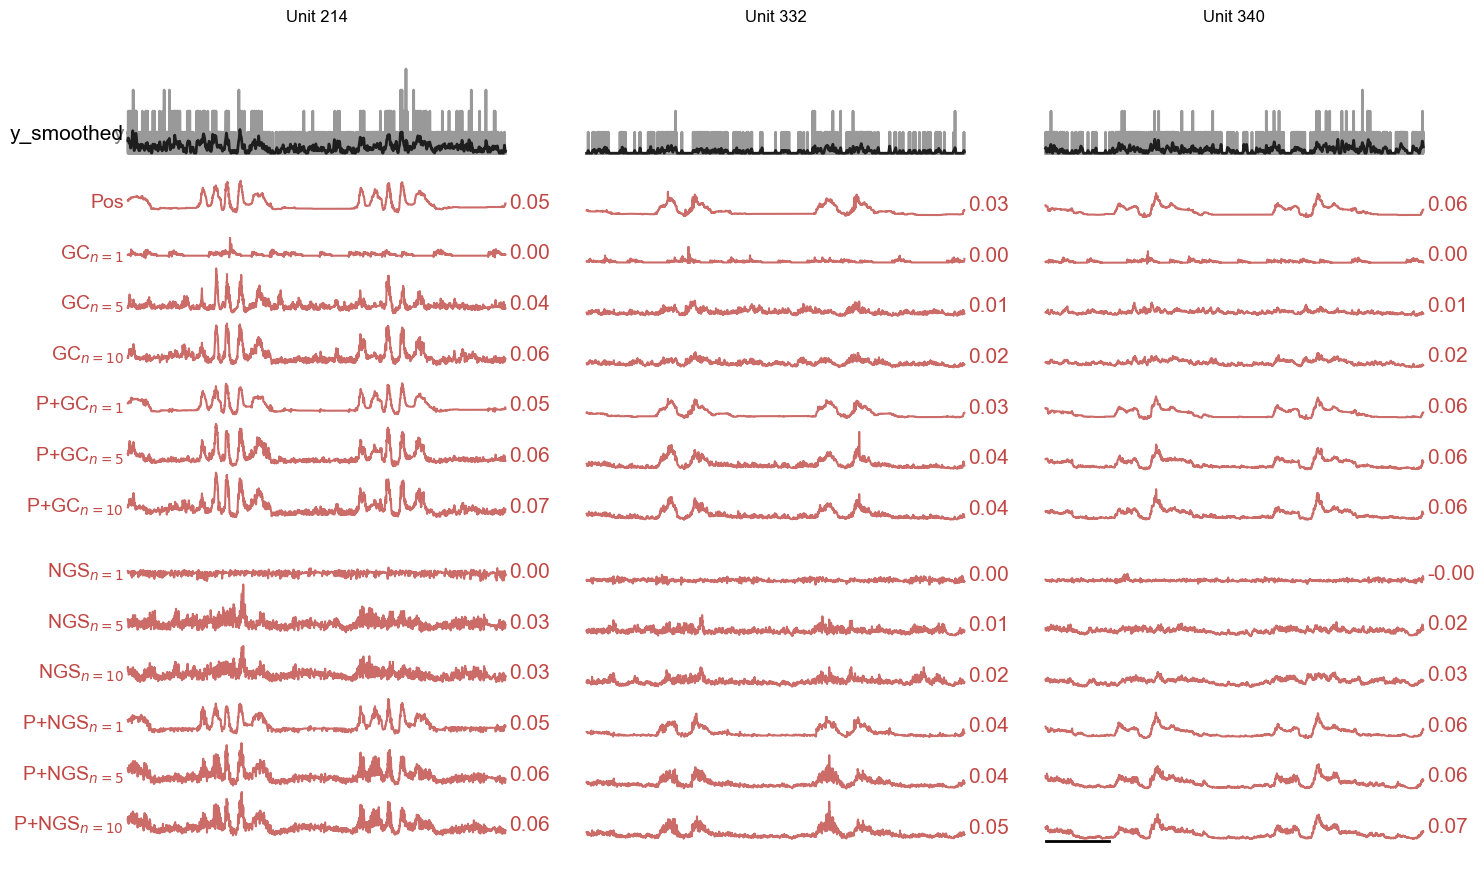

-42000


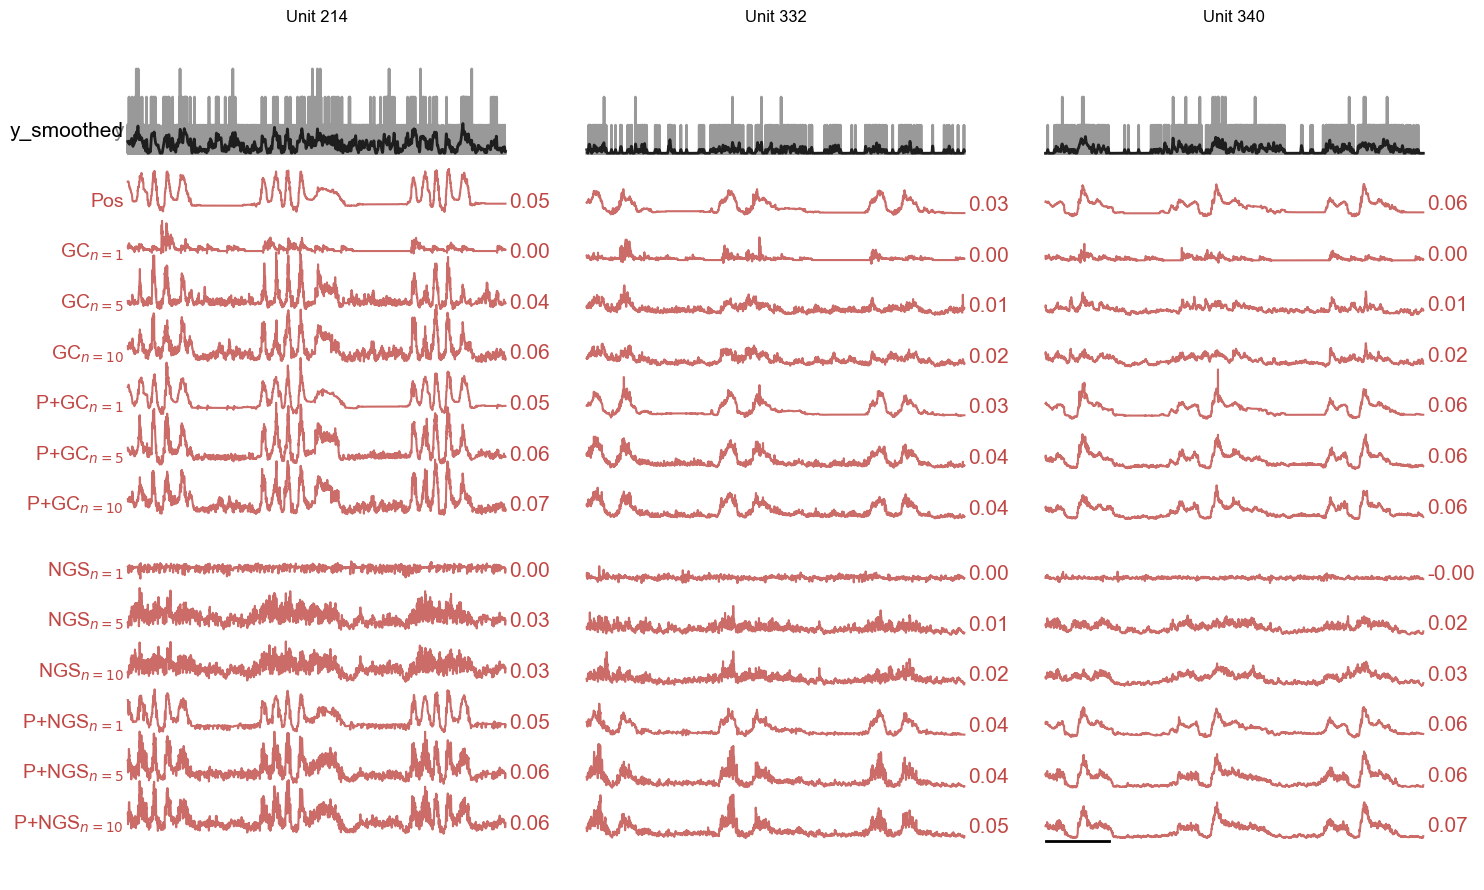

-38000


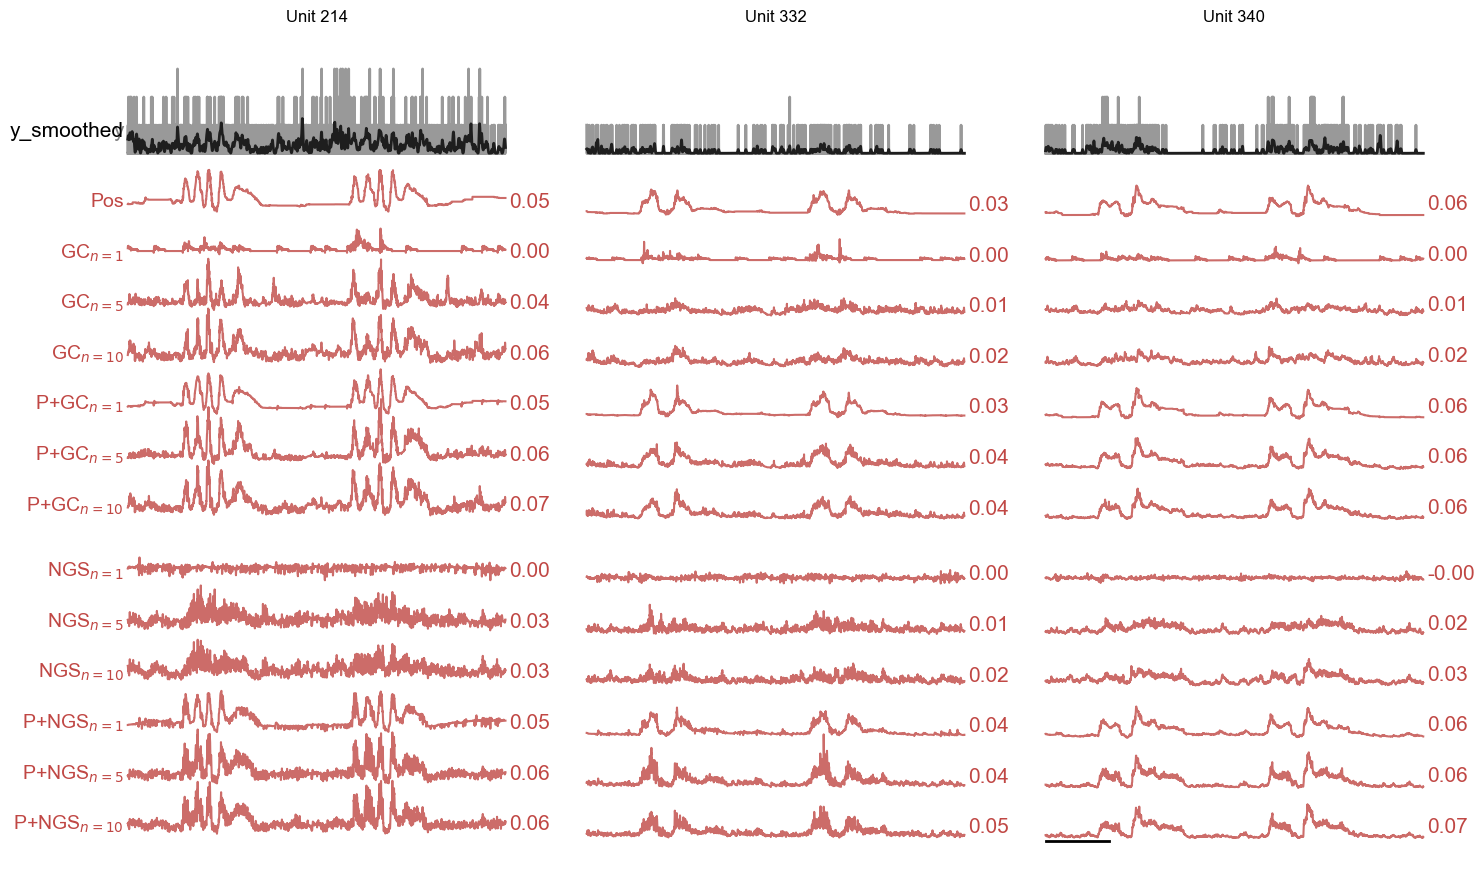

-34000


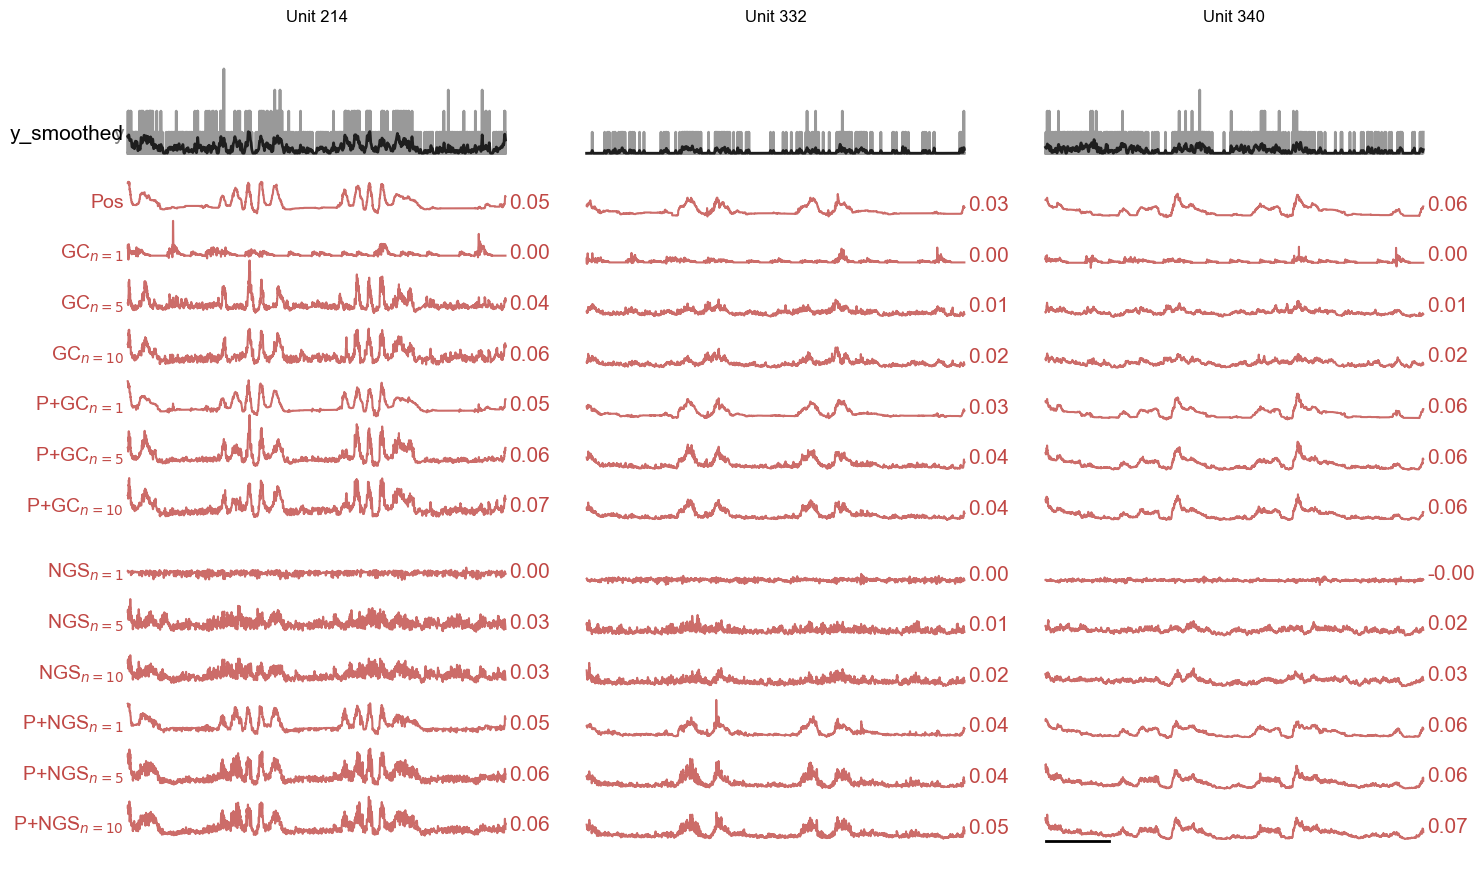

-30000


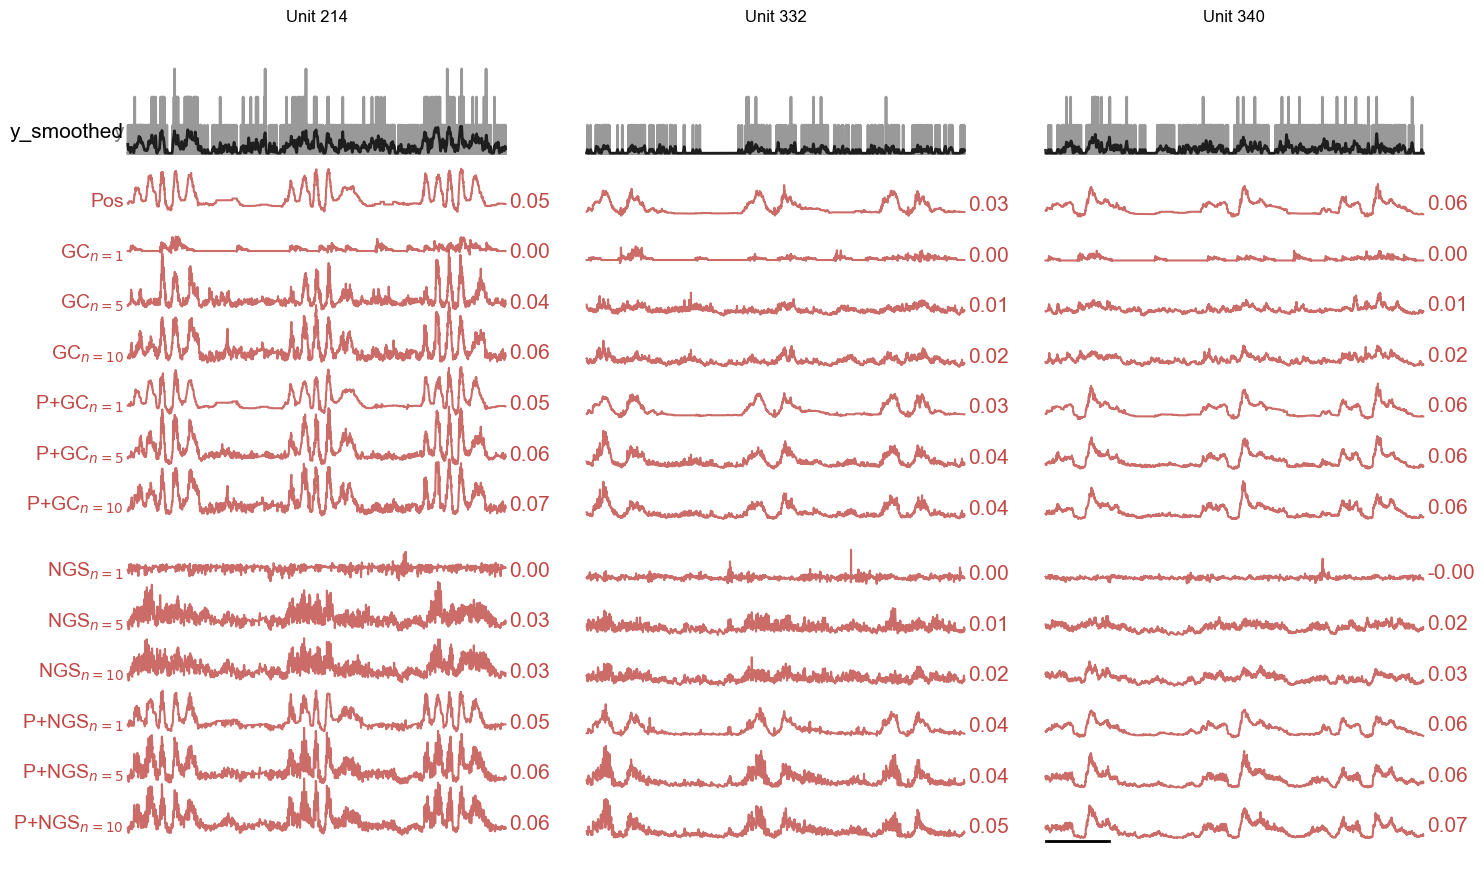

-26000


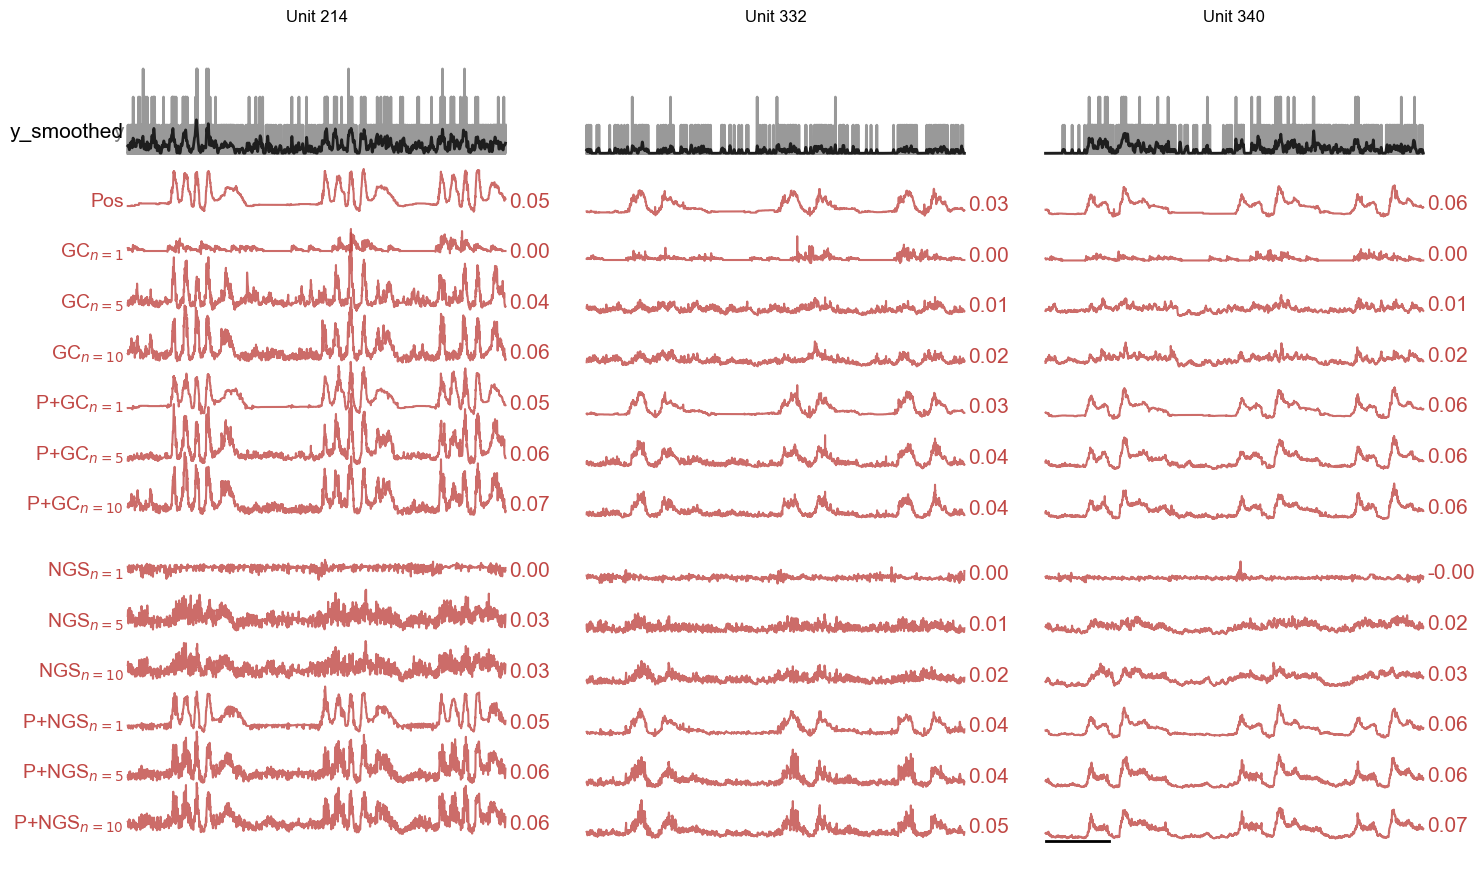

-22000


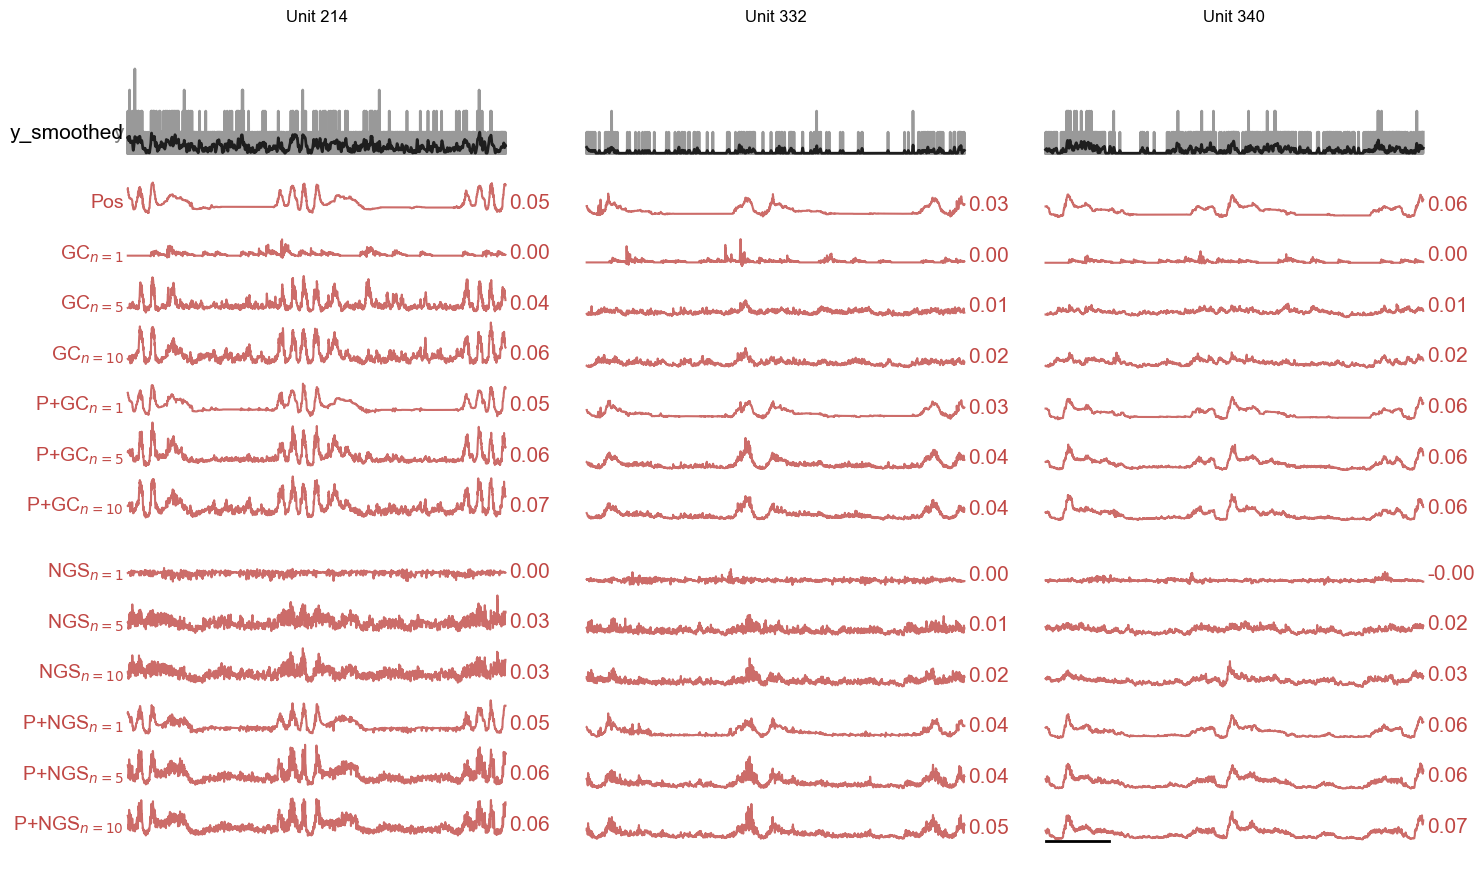

-18000


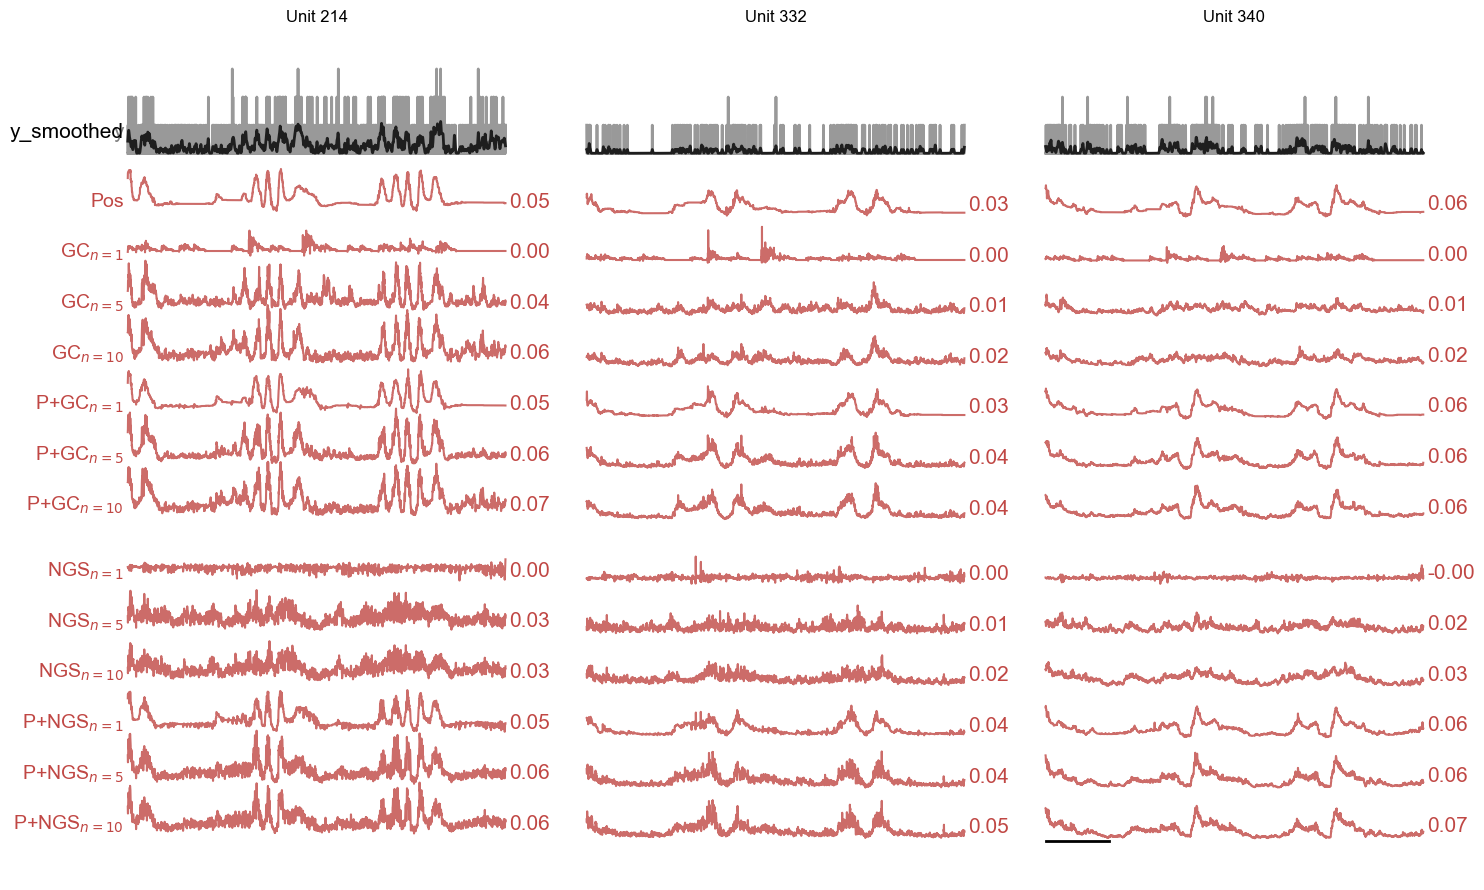

-14000


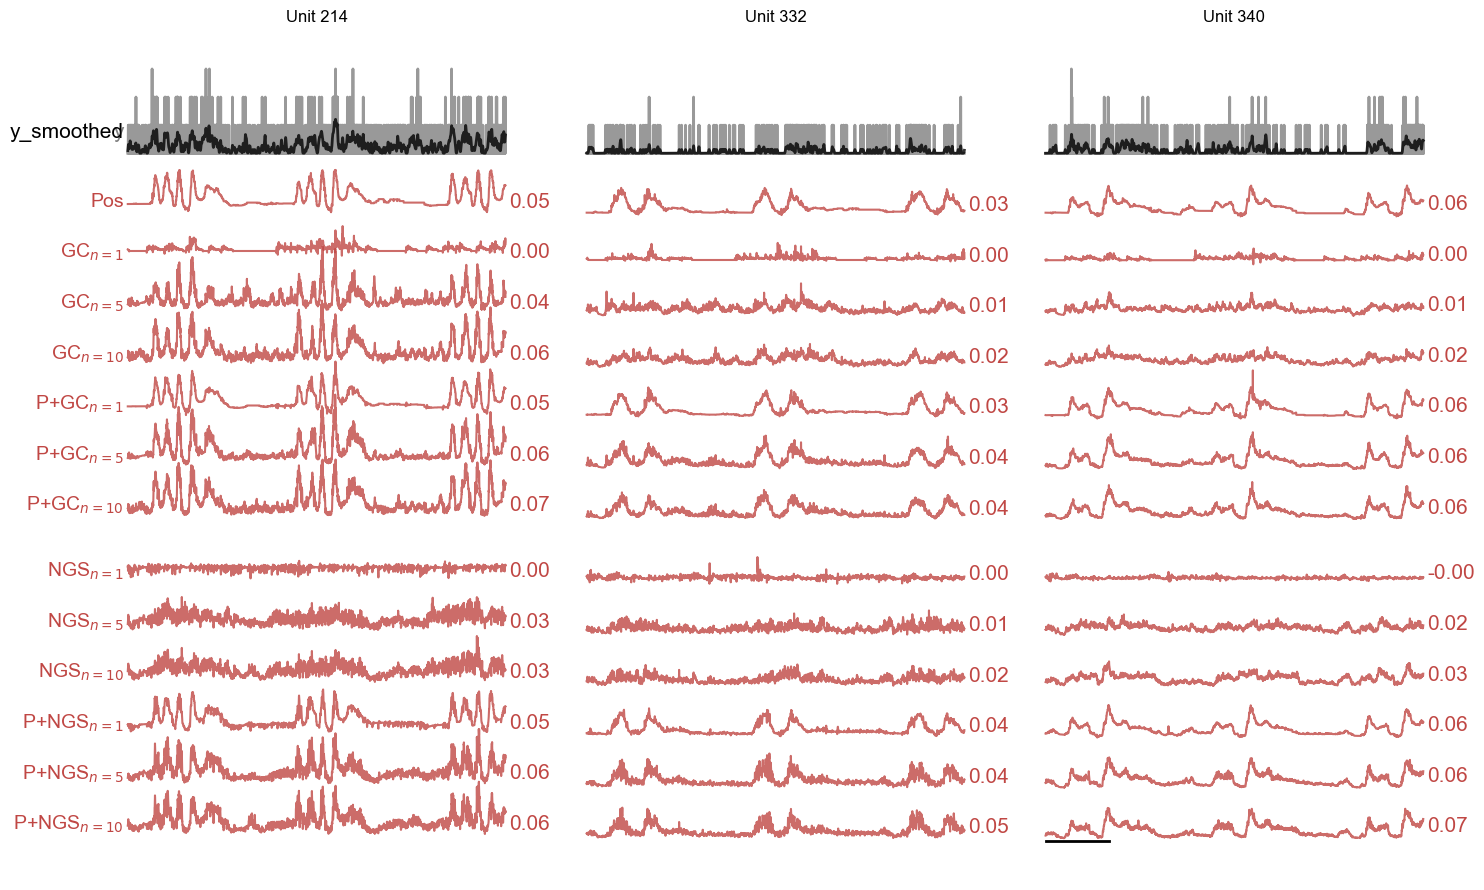

-10000


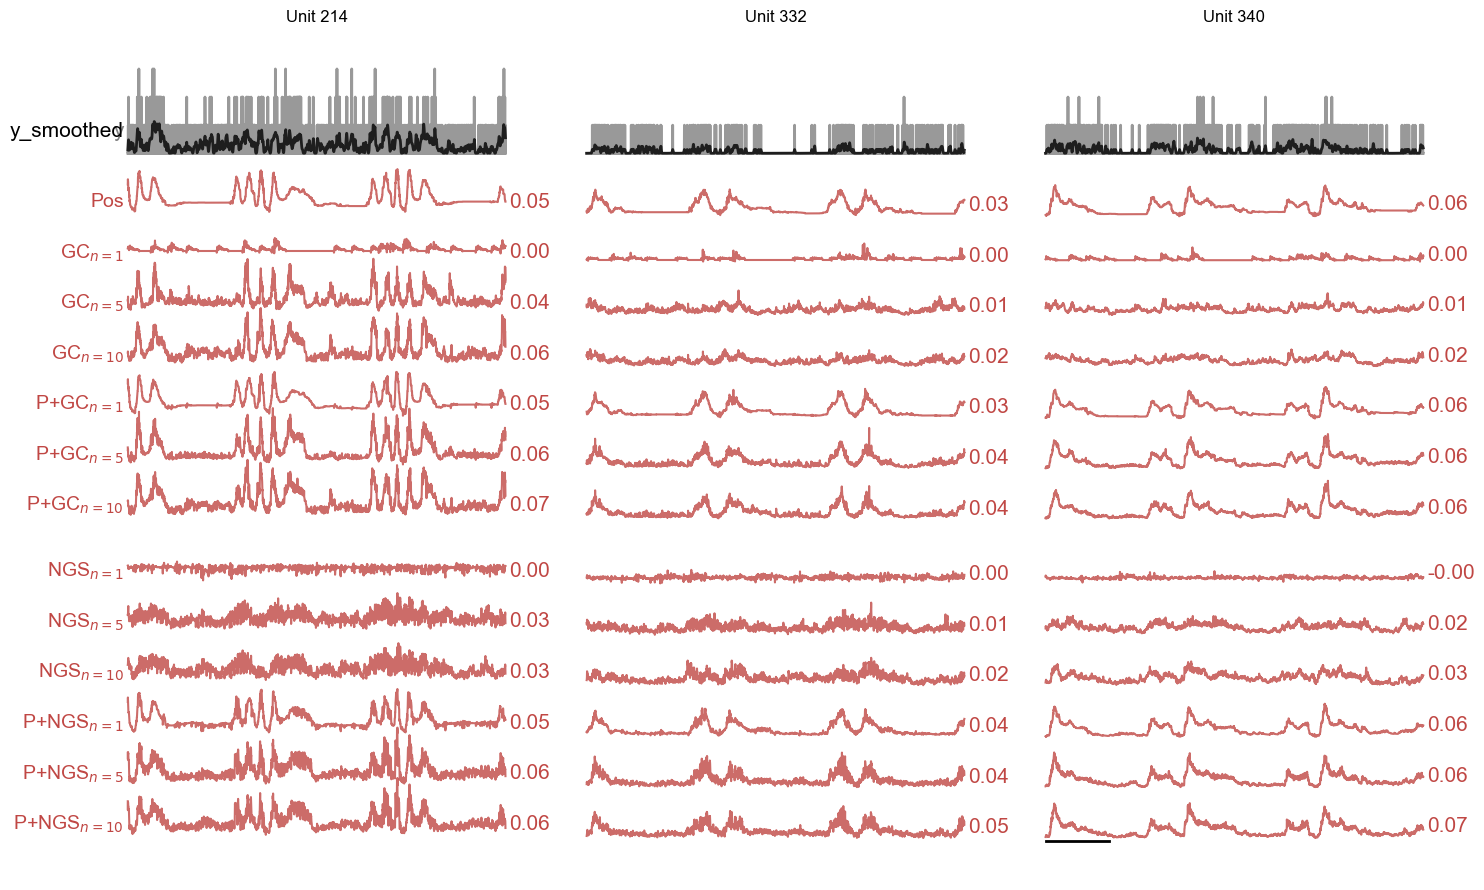

-6000


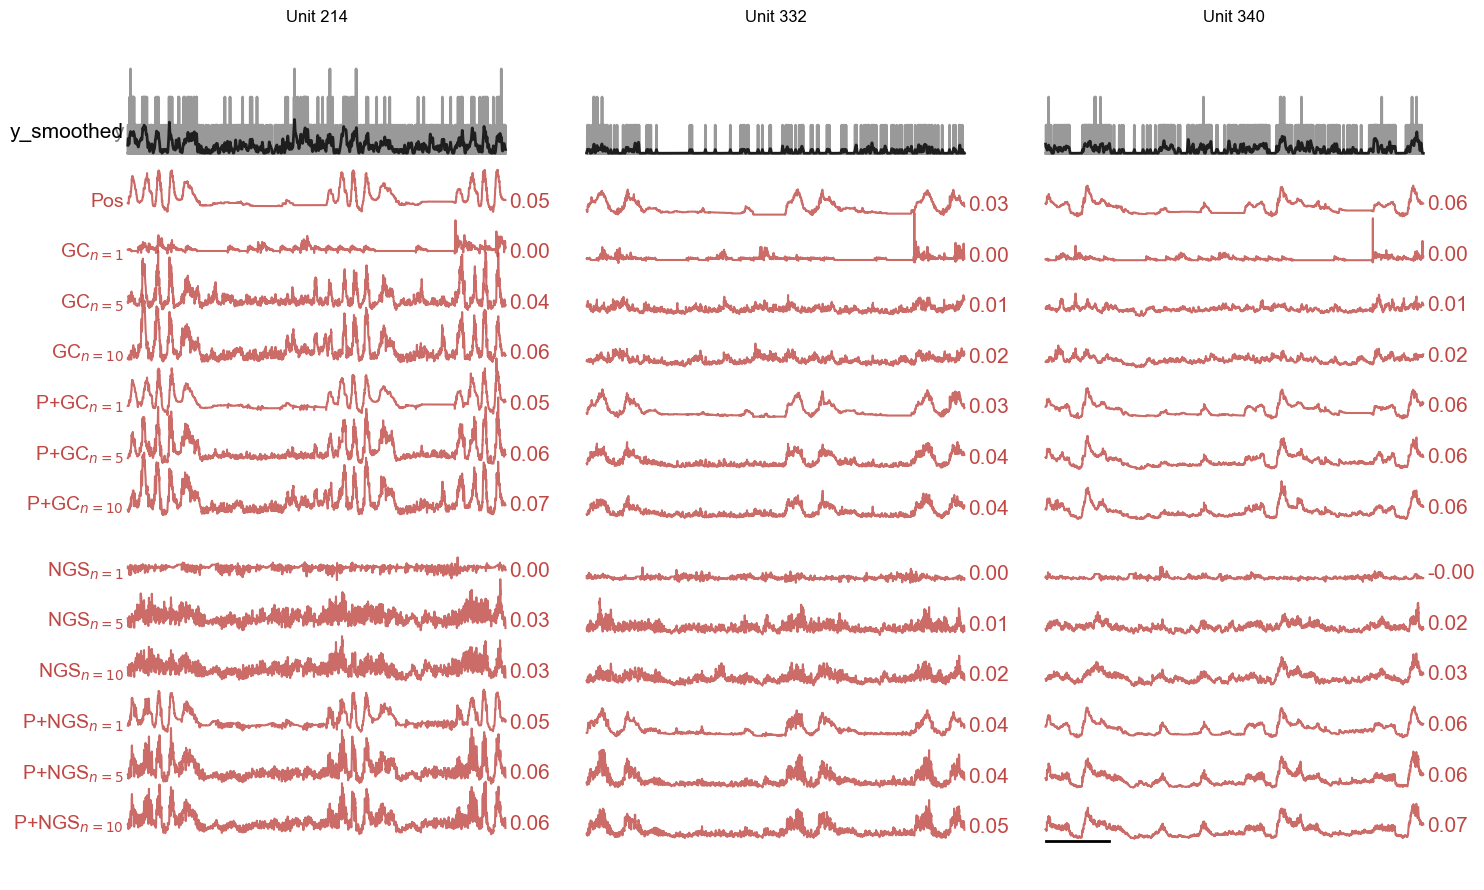

-2000


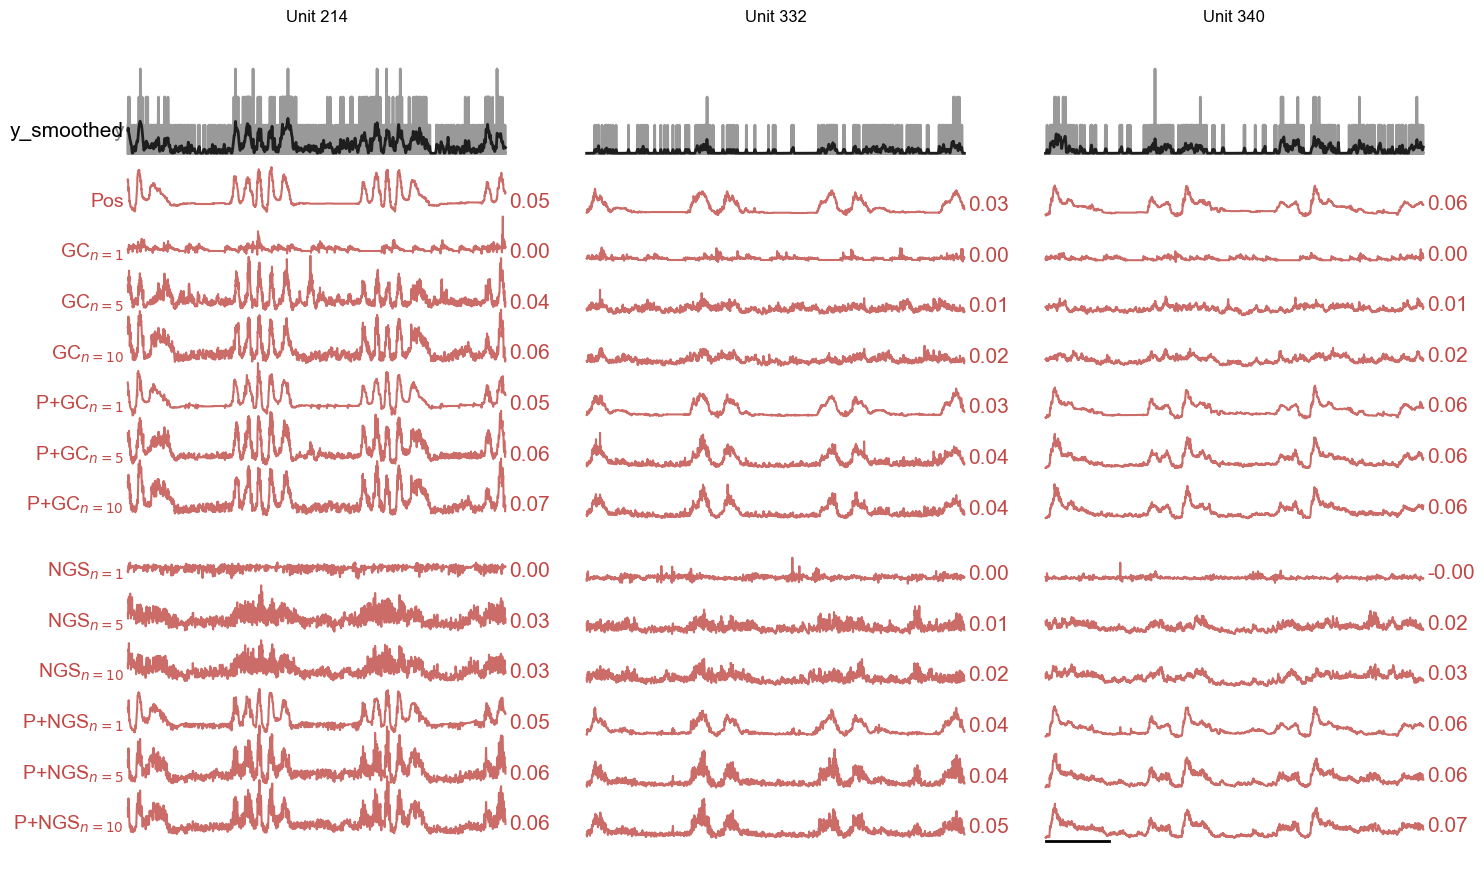

In [89]:
for b in [-54000, -50000, -46000, -42000, -38000, -34000, -30000, -26000, -22000, -18000, -14000, -10000, -6000, -2000]:
    print(b)
    
    # Now you can call the plotting function
    plot_xgboost_traces(results_dict, 
                        target_cell_names,
                        window=(54200+b, 57200+b), 
                        figsize=(15, 9),
                        gain=[5, 12, 6],
                        text_offset=0.25,
                        offset_jump=0.3,
                        savepath=fig_path + f'M{mouse}D{day}_xgboost_traces.pdf')